# IWSLT15 English-Vietnamese Data Preparation

This notebook provides a complete, reproducible pipeline for:
- downloading the IWSLT15 EN-VI dataset,
- performing exploratory data analysis (EDA),
- applying rule-based cleaning,
- saving both raw and cleaned datasets for downstream model training.

## Notebook Flow
1. Environment setup
2. Dataset loading and inspection
3. EDA and quality checks
4. Data cleaning
5. Persist cleaned artifacts

In [13]:
# Install required libraries
!pip install -U -q datasets pandas matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 1. Environment Setup

Import libraries, define data paths, and configure plotting defaults for consistent analysis output.

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Display configuration
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

# Paths
RAW_OUTPUT_DIR = "../data/processed/iwslt15_en_vi"
CLEAN_OUTPUT_DIR = "../data/processed/iwslt15_cleaned"
os.makedirs(RAW_OUTPUT_DIR, exist_ok=True)
os.makedirs(CLEAN_OUTPUT_DIR, exist_ok=True)

print("Environment is ready.")
print(f"Raw output directory: {RAW_OUTPUT_DIR}")
print(f"Clean output directory: {CLEAN_OUTPUT_DIR}")

Environment is ready.
Raw output directory: ../data/processed/iwslt15_en_vi
Clean output directory: ../data/processed/iwslt15_cleaned


## 2. Load and Inspect Raw Dataset

Load the EN-VI dataset from a stable Parquet mirror, inspect split sizes, preview example pairs, and persist a raw snapshot.

In [17]:
print("Loading dataset from Hugging Face Hub...")
dataset = load_dataset("thainq107/iwslt2015-en-vi")

print("\nDataset structure:")
print(dataset)

print("\nFeature columns:")
print(dataset["train"].column_names)

print("\nSplit sizes:")
for split in ["train", "validation", "test"]:
    print(f"- {split}: {len(dataset[split]):,} samples")

# English-only diagnostic preview without printing raw multilingual text
print("\nPreview diagnostics from first 3 training records:")
for idx in range(3):
    en_text = str(dataset["train"][idx]["en"])
    vi_text = str(dataset["train"][idx]["vi"])
    print(
        f"- record {idx}: en_tokens={len(en_text.split())}, "
        f"vi_tokens={len(vi_text.split())}, ratio={len(en_text.split())/max(len(vi_text.split()),1):.3f}"
    )

# Save a raw snapshot for reproducibility
print("\nSaving raw dataset snapshot...")
dataset.save_to_disk(RAW_OUTPUT_DIR)
print(f"Raw dataset saved to: {RAW_OUTPUT_DIR}")

Loading dataset from Hugging Face Hub...

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['en', 'vi'],
        num_rows: 133317
    })
    validation: Dataset({
        features: ['en', 'vi'],
        num_rows: 1268
    })
    test: Dataset({
        features: ['en', 'vi'],
        num_rows: 1268
    })
})

Feature columns:
['en', 'vi']

Split sizes:
- train: 133,317 samples
- validation: 1,268 samples
- test: 1,268 samples

Preview diagnostics from first 3 training records:
- record 0: en_tokens=9, vi_tokens=10, ratio=0.900
- record 1: en_tokens=50, vi_tokens=76, ratio=0.658
- record 2: en_tokens=27, vi_tokens=30, ratio=0.900

Saving raw dataset snapshot...


Saving the dataset (0/1 shards):   0%|          | 0/133317 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1268 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1268 [00:00<?, ? examples/s]

Raw dataset saved to: ../data/processed/iwslt15_en_vi


## 3. Exploratory Data Analysis (EDA)

Build a train DataFrame, check sample alignment, measure sentence lengths, identify anomalies, and visualize distributions.

EDA: sample diagnostics (first 5 pairs)
- pair 0: en_tokens=9, vi_tokens=10, ratio=0.900
- pair 1: en_tokens=50, vi_tokens=76, ratio=0.658
- pair 2: en_tokens=27, vi_tokens=30, ratio=0.900
- pair 3: en_tokens=31, vi_tokens=30, ratio=1.033
- pair 4: en_tokens=13, vi_tokens=18, ratio=0.722

Length statistics:
              len_en         len_vi  len_ratio_en_vi
count  133317.000000  133317.000000     1.333170e+05
mean       20.299399      24.839353     1.501026e+03
std        15.035268      18.791645     3.873206e+05
min         0.000000       0.000000     0.000000e+00
50%        16.000000      20.000000     8.181818e-01
90%        38.000000      47.000000     1.066667e+00
95%        47.000000      59.000000     1.166667e+00
98%        61.000000      76.000000     1.315789e+00
99%        71.000000      89.000000     1.444444e+00
max       628.000000     850.000000     1.000000e+08

Missing value check:
en    0
vi    0
dtype: int64
Empty string pairs: 151


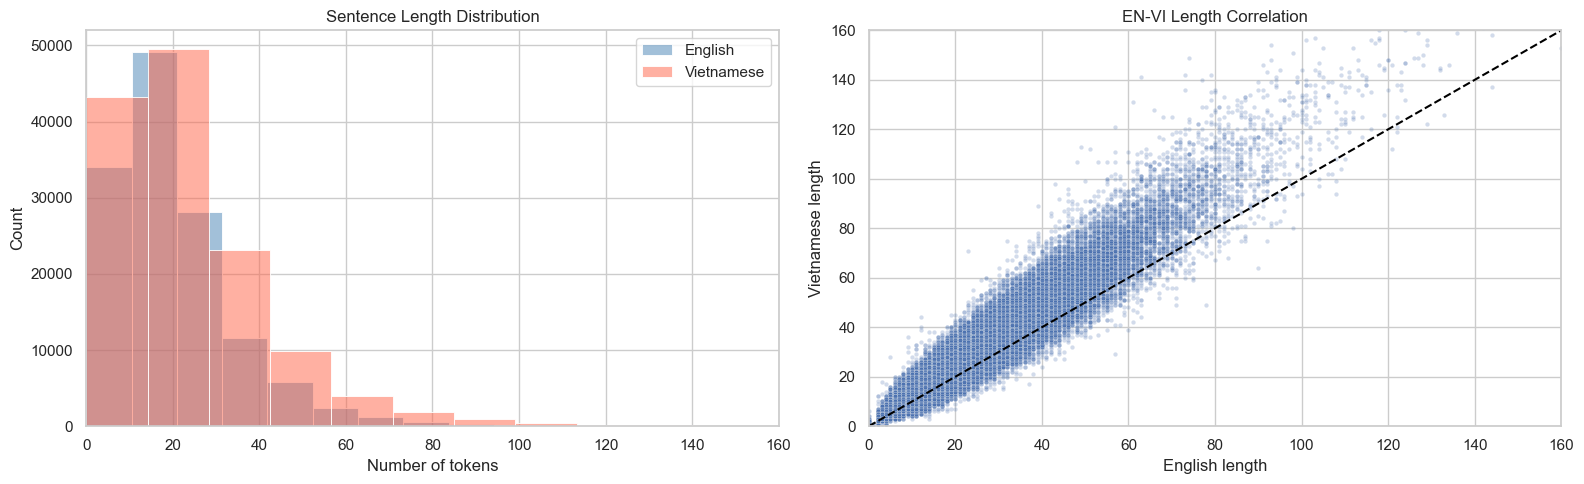

In [18]:
# Convert train split to DataFrame for easier EDA
df = dataset["train"].to_pandas()

# Sample-level diagnostics without printing raw multilingual text
print("EDA: sample diagnostics (first 5 pairs)")
for i in range(5):
    en_len = len(str(df["en"].iloc[i]).split())
    vi_len = len(str(df["vi"].iloc[i]).split())
    ratio = en_len / max(vi_len, 1)
    print(f"- pair {i}: en_tokens={en_len}, vi_tokens={vi_len}, ratio={ratio:.3f}")

# Length-based metrics
df["len_en"] = df["en"].apply(lambda x: len(str(x).split()))
df["len_vi"] = df["vi"].apply(lambda x: len(str(x).split()))
df["len_ratio_en_vi"] = df["len_en"] / (df["len_vi"] + 1e-8)

print("\nLength statistics:")
print(df[["len_en", "len_vi", "len_ratio_en_vi"]].describe(percentiles=[0.5, 0.9, 0.95, 0.98, 0.99]))

# Missing and empty checks
missing_counts = df[["en", "vi"]].isnull().sum()
empty_count = ((df["en"].str.strip() == "") | (df["vi"].str.strip() == "")).sum()

print("\nMissing value check:")
print(missing_counts)
print(f"Empty string pairs: {empty_count}")

# Visual diagnostics
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.histplot(df["len_en"], bins=60, color="steelblue", alpha=0.5, label="English")
sns.histplot(df["len_vi"], bins=60, color="tomato", alpha=0.5, label="Vietnamese")
plt.title("Sentence Length Distribution")
plt.xlabel("Number of tokens")
plt.xlim(0, 160)
plt.legend()

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x="len_en", y="len_vi", alpha=0.25, s=10)
plt.plot([0, 160], [0, 160], linestyle="--", color="black")
plt.title("EN-VI Length Correlation")
plt.xlabel("English length")
plt.ylabel("Vietnamese length")
plt.xlim(0, 160)
plt.ylim(0, 160)

plt.tight_layout()
plt.show()

## 4. Rule-Based Cleaning and Persistence

Apply practical filtering rules derived from EDA (empty text, HTML-like tags, extreme lengths, and severe EN-VI length mismatch), then save the cleaned dataset.

In [19]:
# Cleaning thresholds based on EDA and training practicality
MIN_LEN = 2
MAX_LEN = 80
MAX_RATIO = 2.5


def is_valid_translation_pair(example):
    en_text = str(example["en"]).strip()
    vi_text = str(example["vi"]).strip()

    # 1) Reject empty strings
    if not en_text or not vi_text:
        return False

    en_len = len(en_text.split())
    vi_len = len(vi_text.split())

    # 2) Reject HTML/XML-like noise
    if any(tag in en_text for tag in ["<", ">"]) or any(tag in vi_text for tag in ["<", ">"]):
        return False

    # 3) Reject too short/too long sequences
    if not (MIN_LEN <= en_len <= MAX_LEN and MIN_LEN <= vi_len <= MAX_LEN):
        return False

    # 4) Reject severe length mismatch
    ratio = en_len / max(vi_len, 1)
    if ratio > MAX_RATIO or ratio < (1 / MAX_RATIO):
        return False

    return True


print("Applying cleaning filters to all splits...")
cleaned_dataset = dataset.filter(is_valid_translation_pair)

print("\nCleaning summary:")
for split in ["train", "validation", "test"]:
    original_size = len(dataset[split])
    cleaned_size = len(cleaned_dataset[split])
    removed_size = original_size - cleaned_size
    removed_pct = (removed_size / original_size * 100) if original_size else 0.0
    print(
        f"- {split}: kept {cleaned_size:,}/{original_size:,} "
        f"(removed {removed_size:,}, {removed_pct:.2f}%)"
    )

print("\nSaving cleaned dataset...")
cleaned_dataset.save_to_disk(CLEAN_OUTPUT_DIR)
print(f"Cleaned dataset saved to: {CLEAN_OUTPUT_DIR}")

Applying cleaning filters to all splits...


Filter:   0%|          | 0/133317 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1268 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1268 [00:00<?, ? examples/s]


Cleaning summary:
- train: kept 130,804/133,317 (removed 2,513, 1.88%)
- validation: kept 1,246/1,268 (removed 22, 1.74%)
- test: kept 1,246/1,268 (removed 22, 1.74%)

Saving cleaned dataset...


Saving the dataset (0/1 shards):   0%|          | 0/130804 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1246 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1246 [00:00<?, ? examples/s]

Cleaned dataset saved to: ../data/processed/iwslt15_cleaned
